# Final Results Report — Cross-Domain T-Cell Classification

Compiles all figures and tables for the final report.

**Best model**: GeneAttention v5 — Target Macro-F1 = **0.438**  
**Source**: GSE108989 (Smart-seq2, 6,824 labelled cells)  
**Target**: GSE126030 (10x Genomics, 63,877 unlabelled cells)

## 0 · Imports

In [2]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.metrics import confusion_matrix, f1_score, classification_report

plt.rcParams.update({
    "figure.dpi":    130,
    "font.size":     11,
    "axes.titlesize":12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

PROJECT_ROOT = Path("../..")
OUT_DIR      = Path("report_output")
OUT_DIR.mkdir(exist_ok=True)

with open(PROJECT_ROOT / "step3_label_mapping.json") as f:
    label_map = json.load(f)
class_names = [label_map[str(i)] for i in range(len(label_map))]

print("Classes:", class_names)

Classes: ['Effector', 'Exhausted', 'Naive', 'Other_CD4', 'Th1-like', 'Treg']


## 1 · Model progression table

In [3]:
all_models = pd.DataFrame([
    # Classical baselines
    {"Model": "Logistic Regression",     "Type": "Baseline", "Source F1": 0.650, "Target F1": 0.390},
    {"Model": "Random Forest",            "Type": "Baseline", "Source F1": 0.780, "Target F1": 0.380},
    {"Model": "SVM",                      "Type": "Baseline", "Source F1": 0.894, "Target F1": None},
    # Domain adaptation
    {"Model": "MMD Net",                  "Type": "DA",        "Source F1": 0.850, "Target F1": 0.370},
    {"Model": "DANN v2",                  "Type": "DA",        "Source F1": 0.870, "Target F1": 0.385},
    {"Model": "CDAN-E",                   "Type": "DA",        "Source F1": 0.882, "Target F1": 0.391},
    {"Model": "Joint VAE",                "Type": "DA",        "Source F1": 0.871, "Target F1": 0.395},
    # Gene attention series
    {"Model": "GeneAtt v3",              "Type": "GeneAtt",   "Source F1": 0.896, "Target F1": 0.407},
    {"Model": "GeneAtt v4",              "Type": "GeneAtt",   "Source F1": 0.903, "Target F1": 0.420},
    {"Model": "GeneAtt v5 (best)",       "Type": "GeneAtt",   "Source F1": 0.902, "Target F1": 0.438},
    {"Model": "GeneAtt v6",              "Type": "GeneAtt",   "Source F1": 0.890, "Target F1": 0.392},
])

print(all_models.to_string(index=False))

              Model     Type  Source F1  Target F1
Logistic Regression Baseline      0.650      0.390
      Random Forest Baseline      0.780      0.380
                SVM Baseline      0.894        NaN
            MMD Net       DA      0.850      0.370
            DANN v2       DA      0.870      0.385
             CDAN-E       DA      0.882      0.391
          Joint VAE       DA      0.871      0.395
         GeneAtt v3  GeneAtt      0.896      0.407
         GeneAtt v4  GeneAtt      0.903      0.420
  GeneAtt v5 (best)  GeneAtt      0.902      0.438
         GeneAtt v6  GeneAtt      0.890      0.392


## 2 · Target F1 progression bar chart

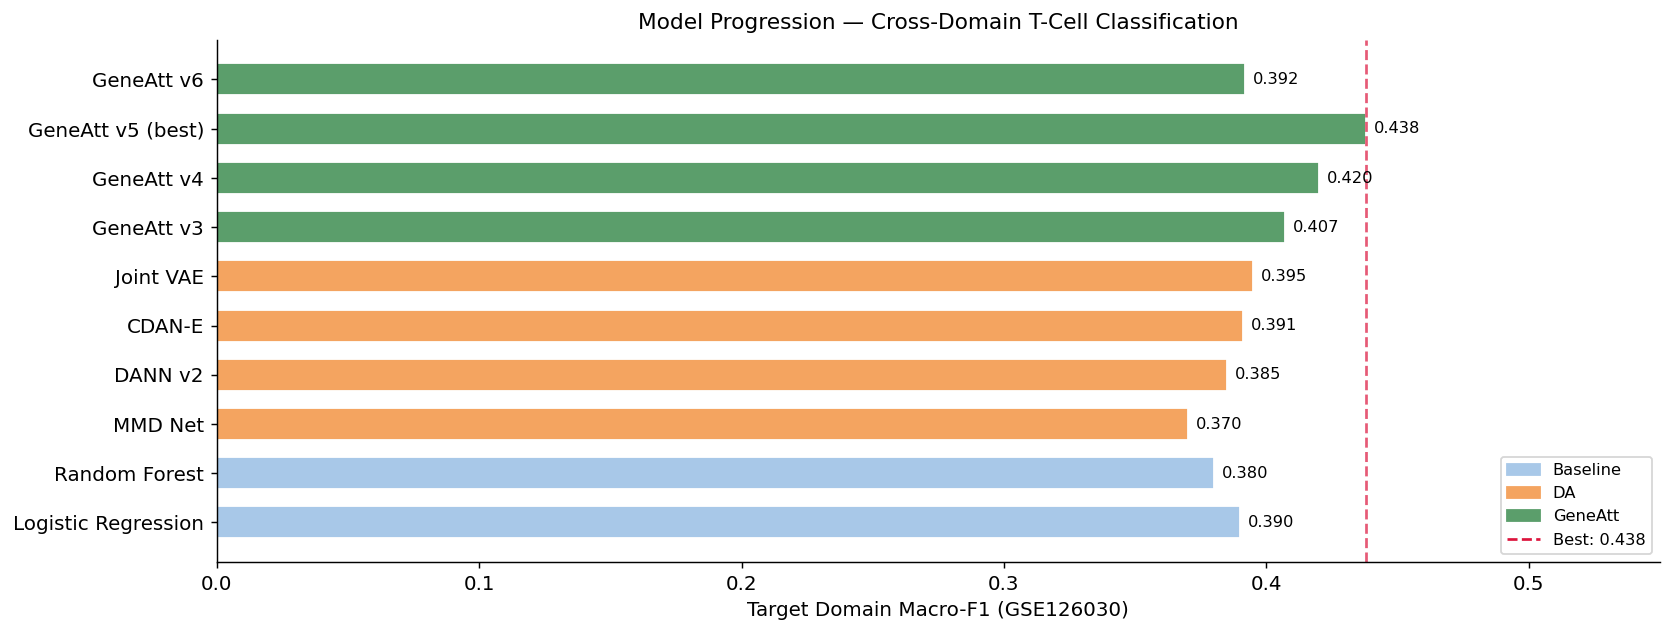

Saved: report_output/model_progression.png


In [4]:
plot_df = all_models.dropna(subset=["Target F1"]).copy()

color_map = {"Baseline": "#a8c8e8", "DA": "#f4a460", "GeneAtt": "#5b9e6b"}
colors = [color_map[t] for t in plot_df["Type"]]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.barh(plot_df["Model"], plot_df["Target F1"], color=colors, edgecolor="white", height=0.65)

# Best model marker
best_val = plot_df["Target F1"].max()
ax.axvline(best_val, color="crimson", lw=1.5, ls="--", alpha=0.7, label=f"Best: {best_val:.3f}")

# Value labels
for bar, val in zip(bars, plot_df["Target F1"]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=9)

# Legend
patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches + [plt.Line2D([0],[0],color='crimson',ls='--',lw=1.5,label=f'Best: {best_val:.3f}')],
          loc="lower right", fontsize=9)

ax.set_xlabel("Target Domain Macro-F1 (GSE126030)")
ax.set_title("Model Progression — Cross-Domain T-Cell Classification")
ax.set_xlim(0, 0.55)
plt.tight_layout()
plt.savefig(OUT_DIR / "model_progression.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_DIR}/model_progression.png")

## 3 · Source vs Target F1 scatter

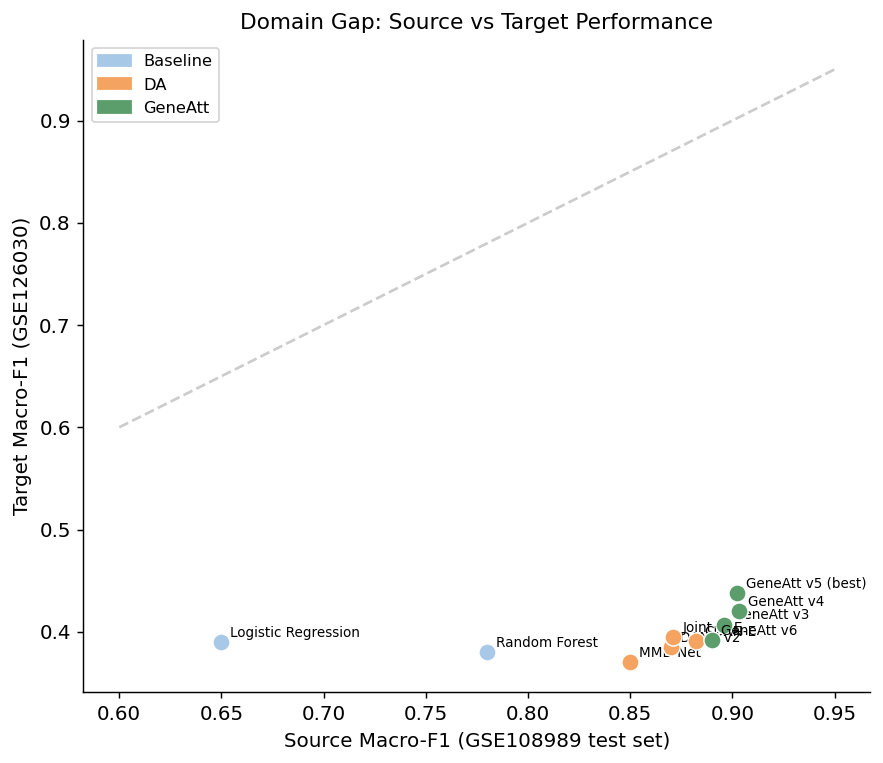

In [5]:
plot2 = all_models.dropna(subset=["Target F1", "Source F1"]).copy()

fig, ax = plt.subplots(figsize=(7, 6))
for _, row in plot2.iterrows():
    ax.scatter(row["Source F1"], row["Target F1"],
               color=color_map[row["Type"]], s=90, zorder=3,
               edgecolors="white", linewidths=0.8)
    ax.annotate(row["Model"], (row["Source F1"], row["Target F1"]),
                textcoords="offset points", xytext=(5, 3), fontsize=7.5)

patches = [mpatches.Patch(color=v, label=k) for k, v in color_map.items()]
ax.legend(handles=patches, fontsize=9)
ax.set_xlabel("Source Macro-F1 (GSE108989 test set)")
ax.set_ylabel("Target Macro-F1 (GSE126030)")
ax.set_title("Domain Gap: Source vs Target Performance")
ax.plot([0.6, 0.95], [0.6, 0.95], "k--", alpha=0.2, label="diagonal")
plt.tight_layout()
plt.savefig(OUT_DIR / "source_vs_target_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 4 · Best model — per-class F1 breakdown

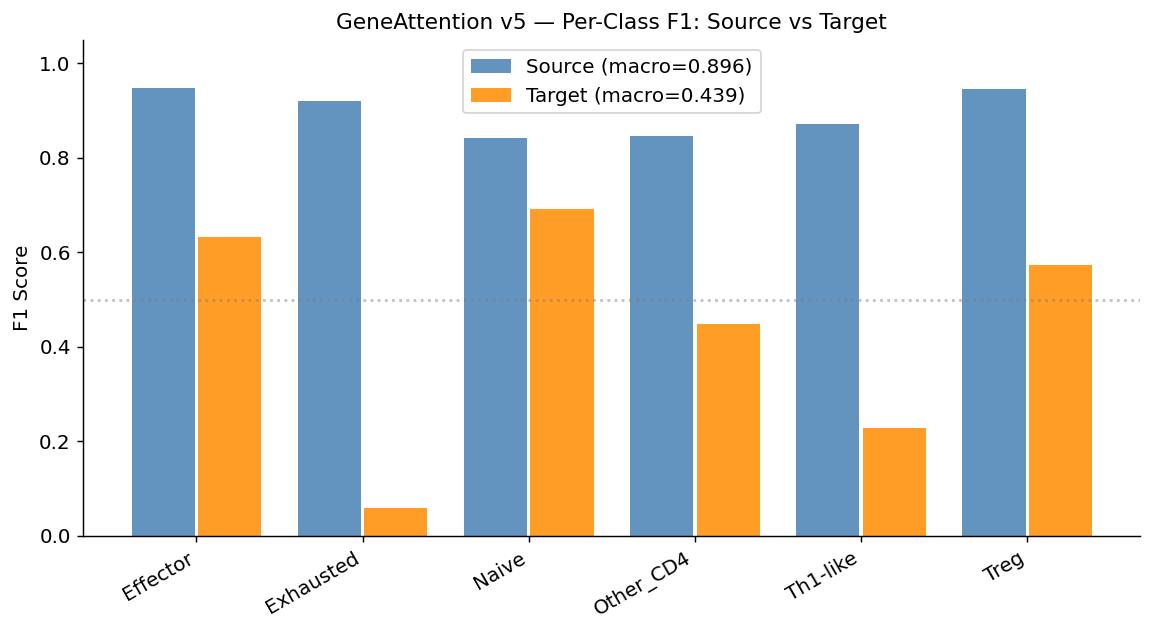

In [6]:
# Load saved v5 results
v5_results_path = PROJECT_ROOT / "experiments/step3_self_attention/results/gene_attention_v5_results.json"
with open(v5_results_path) as f:
    v5 = json.load(f)

src_f1_per = v5["source_test"]["per_class_f1"]
tgt_f1_per = v5["target_eval"]["per_class_f1"]

x = np.arange(len(class_names))
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - 0.2, [src_f1_per[c] for c in class_names], 0.38,
       label=f"Source (macro={v5['source_test']['macro_f1']:.3f})",
       color="steelblue", alpha=0.85)
ax.bar(x + 0.2, [tgt_f1_per[c] for c in class_names], 0.38,
       label=f"Target (macro={v5['target_eval']['macro_f1']:.3f})",
       color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha="right")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.05)
ax.set_title("GeneAttention v5 — Per-Class F1: Source vs Target")
ax.legend()
ax.axhline(0.5, color="gray", ls=":", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR / "per_class_f1_v5.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 · Key improvements timeline

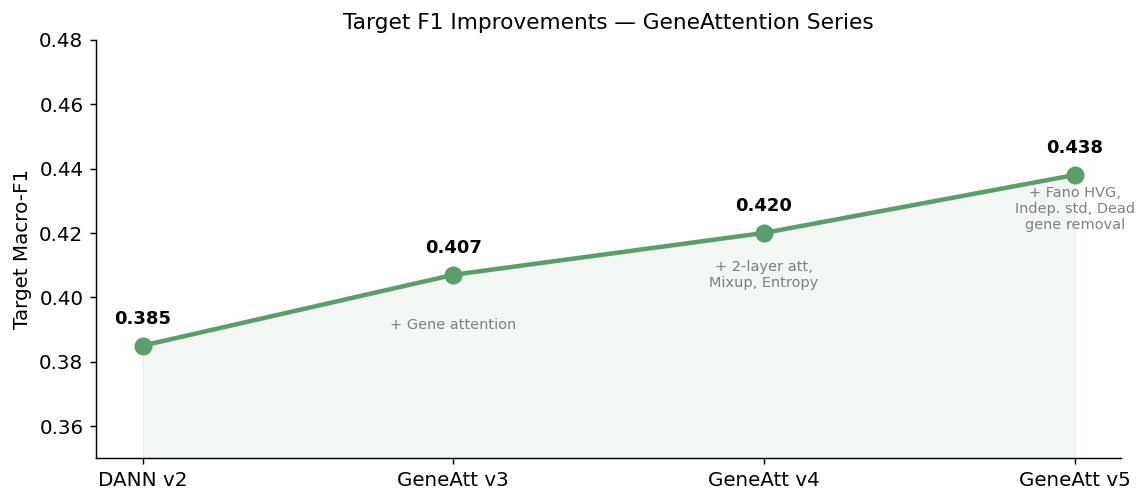

In [7]:
improvements = [
    ("DANN v2",    0.385, ""),
    ("GeneAtt v3", 0.407, "+ Gene attention"),
    ("GeneAtt v4", 0.420, "+ 2-layer att,\nMixup, Entropy"),
    ("GeneAtt v5", 0.438, "+ Fano HVG,\nIndep. std, Dead\ngene removal"),
]

names  = [x[0] for x in improvements]
scores = [x[1] for x in improvements]
labels = [x[2] for x in improvements]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(names)), scores, "o-", color="#5b9e6b", lw=2.5, ms=9, zorder=3)

for i, (s, lbl) in enumerate(zip(scores, labels)):
    ax.annotate(f"{s:.3f}", (i, s), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=10, fontweight="bold")
    if lbl:
        ax.annotate(lbl, (i, s), textcoords="offset points",
                    xytext=(0, -30), ha="center", fontsize=8, color="gray")

ax.set_xticks(range(len(names)))
ax.set_xticklabels(names)
ax.set_ylabel("Target Macro-F1")
ax.set_title("Target F1 Improvements — GeneAttention Series")
ax.set_ylim(0.35, 0.48)
ax.fill_between(range(len(names)), scores, 0.35, alpha=0.08, color="#5b9e6b")
plt.tight_layout()
plt.savefig(OUT_DIR / "improvement_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

## 6 · Confusion matrix — best model (v5 target)

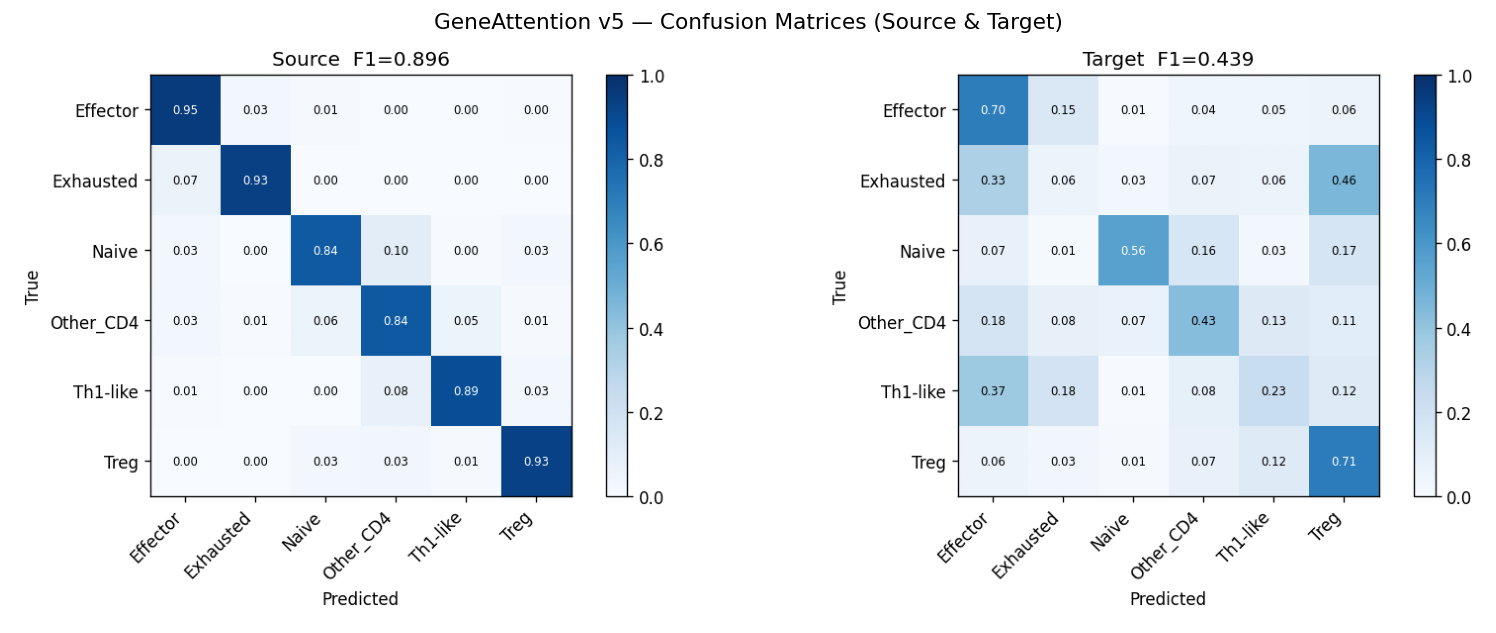

In [8]:
# Load the saved confusion matrix image from v5 results dir
from matplotlib.image import imread

cm_path = PROJECT_ROOT / "experiments/step3_self_attention/results/confusion_matrices_v5.png"
if cm_path.exists():
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.imshow(imread(str(cm_path)))
    ax.axis("off")
    ax.set_title("GeneAttention v5 — Confusion Matrices (Source & Target)", fontsize=12)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "confusion_matrices_best.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"Not found: {cm_path}")
    print("Run 05_gene_attention_v5.ipynb first to generate confusion matrix.")

## 7 · Domain shift summary statistics

In [9]:
X_train = np.load(PROJECT_ROOT / "step3_X_train.npy").astype(np.float32)

# v1 target (old, wrong standardisation)
tgt_v1_path = PROJECT_ROOT / "gse126030_preprocessed.npy"
# v2 target (fixed)
tgt_v2_path = PROJECT_ROOT / "gse126030_preprocessed_v2.npy"

rows = []
rows.append({"Dataset": "Source (train)",
             "Mean": X_train.mean(), "Std (avg/gene)": X_train.std(axis=0).mean()})
if tgt_v1_path.exists():
    t1 = np.load(tgt_v1_path).astype(np.float32)
    rows.append({"Dataset": "Target v1 (wrong scaler)",
                 "Mean": t1.mean(), "Std (avg/gene)": t1.std(axis=0).mean()})
if tgt_v2_path.exists():
    t2 = np.load(tgt_v2_path).astype(np.float32)
    rows.append({"Dataset": "Target v2 (fixed)",
                 "Mean": t2.mean(), "Std (avg/gene)": t2.std(axis=0).mean()})

df_stats = pd.DataFrame(rows)
df_stats["Mean"]           = df_stats["Mean"].map("{:.4f}".format)
df_stats["Std (avg/gene)"] = df_stats["Std (avg/gene)"].map("{:.4f}".format)
print(df_stats.to_string(index=False))
print("\nNote: v1 target std was 8× compressed → CORAL was numerically unstable.")
print("       v2 fix gave +0.018 macro-F1 (largest single improvement in the project).")

                 Dataset    Mean Std (avg/gene)
          Source (train)  0.0011         0.9999
Target v1 (wrong scaler) -0.8529         0.1231
       Target v2 (fixed) -0.0000         0.9999

Note: v1 target std was 8× compressed → CORAL was numerically unstable.
       v2 fix gave +0.018 macro-F1 (largest single improvement in the project).


## 8 · Export full comparison table (CSV + LaTeX)

In [10]:
all_models.to_csv(OUT_DIR / "model_comparison.csv", index=False)

# LaTeX table
latex = all_models.to_latex(
    index=False, float_format="{:.3f}".format, na_rep="—",
    caption="Model comparison: source and target domain macro-F1 scores.",
    label="tab:model_comparison",
)
with open(OUT_DIR / "model_comparison.tex", "w") as f:
    f.write(latex)

print("Saved:")
print(f"  {OUT_DIR}/model_comparison.csv")
print(f"  {OUT_DIR}/model_comparison.tex")
print()
print(latex)

ImportError: Missing optional dependency 'Jinja2'. DataFrame.style requires jinja2. Use pip or conda to install Jinja2.